# Weekly Project 5 
## Implementation of global registration 
### Task 1
Today, your task is to implement a global registration algorithm.

It should be able to roughly align two point clouds.
Implement the global registration, and then try the following:

1. Can you fit `r1.pcd` and `r2.pcd`?
2. Can you fit `car1.ply` and `car2.ply`?
The corresponding files are in the `global_registration` folder.

## 1. Fitting R1.pcd to R2.pcd

In [2]:
import open3d as o3d
import numpy as np
import copy


# helper function for drawing
# If you want it to be more clear set recolor=True
def draw_registrations(source, target, transformation = None, recolor = False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if(recolor):
        source_temp.paint_uniform_color([1, 0.706, 0])
        target_temp.paint_uniform_color([0, 0.651, 0.929])
    if(transformation is not None):
        source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
source = o3d.io.read_point_cloud("global_registration/r1.pcd")
target = o3d.io.read_point_cloud("global_registration/r2.pcd")

# Used for downsampling.
voxel_size = 0.05

# Show models side by side
draw_registrations(source, target)

In [53]:
####
# Downsample and find features here
####

voxel_size=0.05 

# down sample to help computation
source_sample = source.voxel_down_sample(voxel_size)
target_sample = target.voxel_down_sample(voxel_size)

#estimate centroid
source_sample.estimate_normals()
target_sample.estimate_normals()

# Code

radius_normal=voxel_size * 2
search=o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal,max_nn=40)#search parameters

source_fpfh=o3d.pipelines.registration.compute_fpfh_feature(input=source_sample,search_param=search)
target_fpfh=o3d.pipelines.registration.compute_fpfh_feature(input=target_sample,search_param=search)


In [54]:
####
# Call RANSAC here
####

point_to_point =  o3d.pipelines.registration.TransformationEstimationPointToPoint(False) #initialize class object


corr_length = 0.9
distance_threshold = voxel_size * 1.5

c0 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(corr_length)
c1 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
c2 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnNormal(0.095)

checker_list = [c0,c1,c2]


In [55]:
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_sample, target_sample, 
    source_fpfh, target_fpfh, 
    True,
    distance_threshold,
    point_to_point,
    checkers = checker_list)

draw_registrations(source, target, ransac_result.transformation, True)

## Fitting car1.ply to car2.ply 

In [96]:
source = o3d.io.read_point_cloud("global_registration/car1.ply")
target = o3d.io.read_point_cloud("global_registration/car2.ply")

# Used for downsampling.
voxel_size = 0.05

# Show models side by side
draw_registrations(source, target)

In [97]:
####
# Downsample and find features here
####

# down sample to help computation
source_sample = source.voxel_down_sample(voxel_size)
target_sample = target.voxel_down_sample(voxel_size)

#estimate centroid
source_sample.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(
        radius=radius_normal,
        max_nn=30
    )
)

target_sample.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(
        radius=radius_normal,
        max_nn=30
    )
)

o3d.visualization.draw_geometries(
    [source_sample, target_sample],
    point_show_normal=True
)
# Code

radius_normal=voxel_size * 5
search=o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal,max_nn=100)#search parameters

source_fpfh=o3d.pipelines.registration.compute_fpfh_feature(input=source_sample,search_param=search)
target_fpfh=o3d.pipelines.registration.compute_fpfh_feature(input=target_sample,search_param=search)


In [98]:
####
# Call RANSAC here
####

point_to_point =  o3d.pipelines.registration.TransformationEstimationPointToPoint(False) #initialize class object


corr_length = 0.9
distance_threshold = voxel_size * 1.5

c0 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(corr_length)
c1 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
c2 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnNormal(0.095)

checker_list = [c0,c1]


In [107]:
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_sample, target_sample, 
    source_fpfh, target_fpfh, 
    True,
    distance_threshold,
    point_to_point,
    checkers = checker_list)
threshold = 0.05
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, ransac_result.transformation)
print(evaluation)

draw_registrations(source, target, ransac_result.transformation, True)

RegistrationResult with fitness=9.983816e-01, inlier_rmse=1.546501e-02, and correspondence_set size of 165949
Access transformation to get result.


### Task 2 (Challange)
Challanges attempt either or both:
- Implement local registration.

- Attempt to reconstruct the car from the images in `car_challange` folder.

You can use the notebooks from Monday as a starting point.

In [108]:
# with point to point 
icp_result = o3d.pipelines.registration.registration_icp(source,target,threshold,ransac_result.transformation)

draw_registrations(source, target, icp_result.transformation, True)
draw_registrations(source, target, icp_result.transformation)

evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, icp_result.transformation)
print(evaluation)

RegistrationResult with fitness=9.989712e-01, inlier_rmse=7.426752e-03, and correspondence_set size of 166047
Access transformation to get result.


In [109]:
# with point to plane: 
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
icp_result = o3d.pipelines.registration.registration_icp(source,target,threshold,ransac_result.transformation,point_to_plane)

draw_registrations(source, target, icp_result.transformation, True)
draw_registrations(source, target, icp_result.transformation)

evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, icp_result.transformation)
print(evaluation)

RegistrationResult with fitness=9.989351e-01, inlier_rmse=6.251623e-03, and correspondence_set size of 166041
Access transformation to get result.


### Explaination
Here we see that doing ICP on point to point and point to plane result in similar fitness scores to the global alignment, albeit both are lower by 0.006 m. Point to point had a slightly higher result than point to plane in ICP with 3.61e-5 m difference. The inlier_rmse is clearly lower with ICP than just global alignment with around a factor of 10. The difference betweeen point to point and point to plane is 1.175e-3 m. Both ICP methods have about a 100 extra correspondences, with the point to point have 6 more correspondencesthan the point to plane method. 

## Attempt to reconstruct the car from the images in `car_challange` folder.

In [18]:
import open3d as o3d
import matplotlib.pyplot as plt
import numpy as np
import copy

def draw_registrations(source, target, transformation = None, recolor = False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if(recolor):
        source_temp.paint_uniform_color([1, 0.706, 0])
        target_temp.paint_uniform_color([0, 0.651, 0.929])
    if(transformation is not None):
        source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

In [19]:
# 0000001 to 0001729.png
color_raw0 = o3d.io.read_image("car_challange/rgb/0000001.jpg")
depth_raw0 = o3d.io.read_image("car_challange/depth/0000001.png")

color_raw1 = o3d.io.read_image("car_challange/rgb/0000005.jpg")
depth_raw1 = o3d.io.read_image("car_challange/depth/0000005.png")

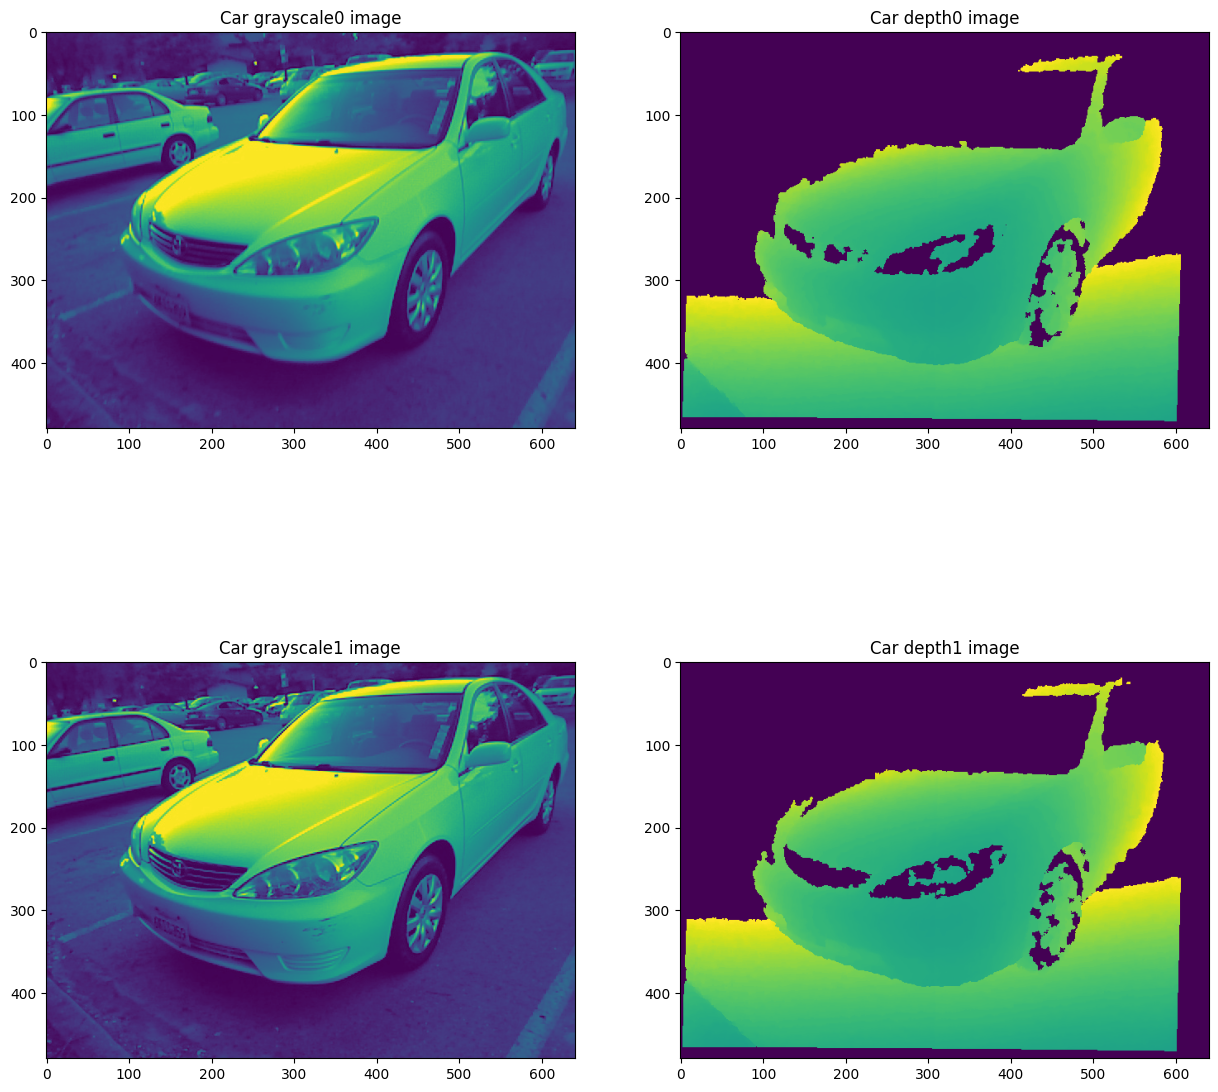

In [20]:
rgbd_image0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw0, 
    depth_raw0, 
    convert_rgb_to_intensity = True)

rgbd_image1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw1, 
    depth_raw1, 
    convert_rgb_to_intensity = True)

#show images
fig= plt.figure(figsize=(15,15))
plt.subplot(221)
plt.title('Car grayscale0 image')
plt.imshow(rgbd_image0.color)

plt.subplot(222)
plt.title('Car depth0 image')
plt.imshow(rgbd_image0.depth)

plt.subplot(223)
plt.title('Car grayscale1 image')
plt.imshow(rgbd_image1.color)

plt.subplot(224)
plt.title('Car depth1 image')
plt.imshow(rgbd_image1.depth)

plt.show()


In [21]:
# Source pointcloud
camera = o3d.camera.PinholeCameraIntrinsic(o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

source = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image0, camera)

# Target pointcloud
target = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image1, camera)

# Flip it, otherwise the pointcloud will be upside down
source.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
target.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

# Draw
draw_registrations(source, target, recolor=True)


In [22]:
threshold = 0.05

trans_init = np.asarray([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]]) # identity 4x4

#Evaluate registration
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

Initial alignment
RegistrationResult with fitness=9.964504e-01, inlier_rmse=2.264208e-02, and correspondence_set size of 165628
Access transformation to get result.


In [23]:
###
# ICP code here
###

point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
icp_result = o3d.pipelines.registration.registration_icp(source,target,threshold,trans_init)

draw_registrations(source, target, icp_result.transformation, True)
draw_registrations(source, target, icp_result.transformation)

Now to try with the for loop implementation: 

In [ ]:
import glob

color_raw = sorted(glob.glob("car_challange/rgb/*.jpg"))
depth_raw = sorted(glob.glob("car_challange/depth/*.png"))

print("Number of color images:", len(color_raw))
print("Number of depth images:", len(depth_raw))

camera = o3d.camera.PinholeCameraIntrinsic(o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault) # get intrinsics

images_color = []
images_depth = []

for path in color_raw:
    img = o3d.io.read_image(path)
    images_color.append(img)

for path in depth_raw:
    img = o3d.io.read_image(path)
    images_depth.append(img)



frame_step=5 # stepping every 5 frames

n_frames = min(len(images_color), len(images_depth)) # max number of frames decided by using the smallest length

threshold = 0.05

trans_init = np.identity(4 )# lets start with identity 4x4


for i in range(0,n_frames-frame_step,frame_step):

    rgbd_image0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    images_color[i], 
    images_depth[i], 
    convert_rgb_to_intensity = True)

    rgbd_image1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    images_color[i+frame_step], 
    images_depth[i+frame_step], 
    convert_rgb_to_intensity = True)

    #source point cloud 
    source = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image0, camera)

    # Target pointcloud
    target = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image1, camera)


    # Flip it, otherwise the pointcloud will be upside down
    source.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
    target.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

    #estimate normals on point clouds
    source.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )

    target.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )


    icp_result = o3d.pipelines.registration.registration_icp(source,target,threshold,trans_init)

    print(
        f"{i} -> {i + frame_step}: "
        f"fitness={icp_result.fitness:.3f}, "
        f"rmse={icp_result.inlier_rmse:.4f}"
    )


Number of color images: 1722
Number of depth images: 1729


AttributeError: 'open3d.cuda.pybind.geometry.RGBDImage' object has no attribute 'estimate_normals'